# Audio & Speech Single Video Analysis
Portuguese presidential debate dataset — 28 debate videos, 2656 audio segments, 8 candidates.

**Main questions:**
1. What do the acoustic features look like globally?
2. Do speaker embeddings separate the 3 speakers in each debate?
3. Can we match those clusters back to named candidates across debates?
4. What does the cleanest debate (`Martins_vs_Gouveia_Melo_November_23`) reveal in detail?
5. What candidate-level acoustic patterns and transcript-level patterns emerge across the campaign?

**Notebook structure:**
- Part I — audio dataset loading and feature setup
- Part II — single-debate case study: Martins vs Gouveia Melo

## Part I — Audio dataset loading and feature setup

In [8]:
import sys, os
# works whether Jupyter is started from project root or from a subfolder
sys.path.insert(0, 'multivideo_analysis')
sys.path.insert(0, '../multivideo_analysis')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

%load_ext autoreload
%autoreload 2
from pipelines import (build_labeled_audio, extract_candidates,
                       CANDIDATES, KEY_FEATURES, NON_REDUNDANT, CAND_COLOR)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
FEATURES_DIR = '../Project_Features'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
data = build_labeled_audio()

build_labeled_audio: 2656 segments | 28 debates | 9 unique speakers


In [10]:
debate_videos     = sorted(v for v in data['video'].unique() if 'vs' in v)
candidate_to_party = (data[data['speaker'].isin(CANDIDATES)]
                      .drop_duplicates('speaker')
                      .set_index('speaker')['party']
                      .to_dict())

## Part II — Single-debate case study: Martins vs Gouveia Melo

We validate on `Martins_vs_Gouveia_Melo_November_23` — the highest silhouette score (0.692),
meaning the cleanest three-cluster separation.

This part contains three complementary views:
1. label validation in embedding space + speaking time split
2. temporal turn-taking through the debate
3. a focused acoustic comparison of `Martins`, `Gouveia_Melo`, and the `host`

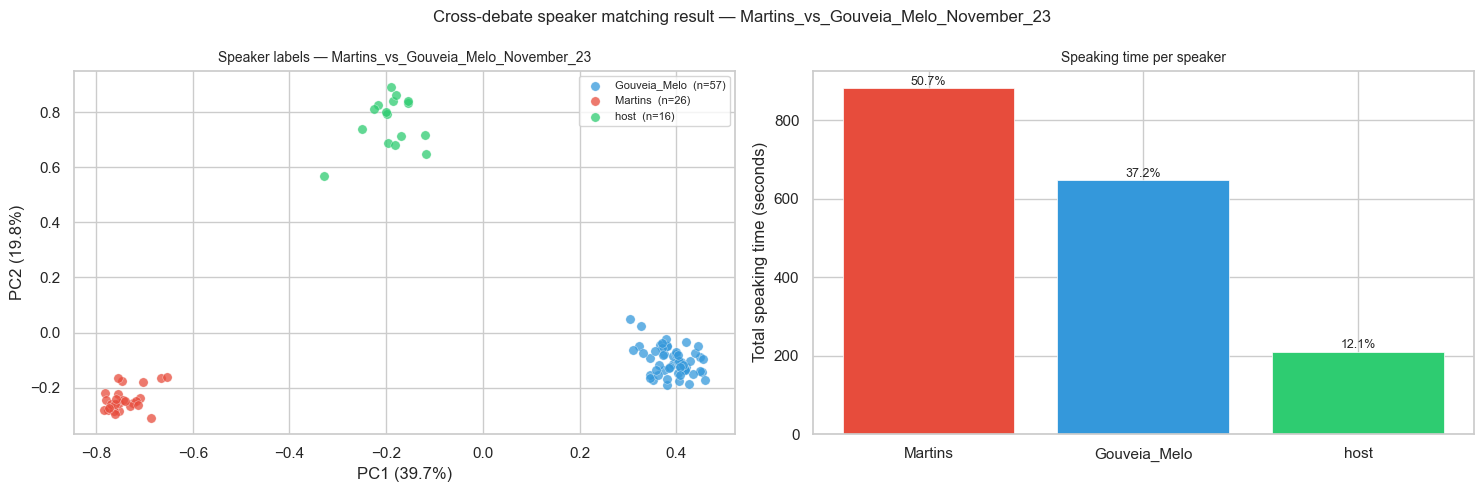

In [11]:
DEBATE = 'Martins_vs_Gouveia_Melo_November_23'

debate_data = data[data['video'] == DEBATE].copy().reset_index(drop=True)
E = np.stack(debate_data['speak_embeddings'].values)

pca = PCA(n_components=2, random_state=42)
E_2d = pca.fit_transform(E)

speakers = debate_data['speaker'].values
unique_speakers = sorted(set(speakers))
colors = {'Martins': '#e74c3c', 'Gouveia_Melo': '#3498db', 'host': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for spk in unique_speakers:
    mask = speakers == spk
    ax.scatter(E_2d[mask, 0], E_2d[mask, 1],
               c=colors.get(spk, '#888888'), label=f'{spk}  (n={mask.sum()})',
               alpha=0.75, s=45, edgecolors='white', linewidth=0.3)
ax.set_title(f'Speaker labels — {DEBATE}', fontsize=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=8)

ax = axes[1]
time_per_speaker = debate_data.groupby('speaker')['duration'].sum().sort_values(ascending=False)
total_time = time_per_speaker.sum()

bars = ax.bar(
    time_per_speaker.index, time_per_speaker.values,
    color=[colors.get(s, '#888888') for s in time_per_speaker.index],
    edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, time_per_speaker.values):
    pct = val / total_time * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Total speaking time (seconds)')
ax.set_title('Speaking time per speaker', fontsize=10)

plt.suptitle(f'Cross-debate speaker matching result — {DEBATE}', fontsize=12)
plt.tight_layout()
plt.show()

for spk, t in time_per_speaker.items():
    pct = t / total_time * 100
    n   = (debate_data['speaker'] == spk).sum()

In [ ]:
# For one debate, plot each audio segment as a horizontal bar on a time axis.
# Colored by k=3 cluster label (no candidate names — purely geometric).
# Shows turn-taking rhythm, turn lengths, and whether one cluster (host)
# has visibly shorter and more evenly-spaced interjections.

TIMELINE_DEBATE = 'Martins_vs_Gouveia_Melo_November_23'  # highest silhouette score

dbt = data[data['video'] == TIMELINE_DEBATE].copy().sort_values('time stamp').reset_index(drop=True)

# k=3 labels for this debate (already computed in cluster_k3 column)
cluster_colors = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}
cluster_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

fig, ax = plt.subplots(figsize=(18, 3))

for _, row in dbt.iterrows():
    c = int(row['cluster_k3'])
    ax.barh(
        y=c,
        width=row['duration'],
        left=row['time stamp'],
        height=0.6,
        color=cluster_colors[c],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.3
    )

ax.set_yticks([0, 1, 2])
ax.set_yticklabels([cluster_labels[i] for i in [0, 1, 2]], fontsize=10)
ax.set_xlabel('Time (seconds)', fontsize=11)
ax.set_title(
    f'Turn-taking timeline — {TIMELINE_DEBATE.replace("_", " ")}\n'
    f'Each bar = one audio segment, colored by k=3 cluster (no speaker identity assumed)',
    fontsize=11
)
ax.set_xlim(0, dbt['time stamp'].max() + dbt['duration'].max())

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cluster_colors[i], label=cluster_labels[i]) for i in range(3)]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Print basic turn stats per cluster
for c in [0, 1, 2]:
    sub = dbt[dbt['cluster_k3'] == c]

In [ ]:
from scipy.stats import mannwhitneyu

FOCUS_DEBATE = 'Martins_vs_Gouveia_Melo_November_23'
FOCUS_SPEAKERS = ['Martins', 'Gouveia_Melo', 'host']
FOCUS_FEATURES = [
    ('meanF0Hz',  'Mean pitch (Hz)'),
    ('stdevF0Hz', 'Pitch variability (Hz)'),
    ('HNR',       'HNR'),
    ('speechrate','Speech rate'),
    ('f1_mean',   'F1 mean (Hz)'),
    ('f2_mean',   'F2 mean (Hz)'),
]

focus_palette = {'Martins': '#e74c3c', 'Gouveia_Melo': '#3498db', 'host': '#2ecc71'}
focus_order = FOCUS_SPEAKERS

focus_data = data[
    (data['video'] == FOCUS_DEBATE) &
    (data['speaker'].isin(FOCUS_SPEAKERS))
].copy()

focus_summary = focus_data.groupby('speaker').agg(
    segments=('duration', 'size'),
    total_duration=('duration', 'sum'),
    mean_duration=('duration', 'mean'),
    median_duration=('duration', 'median')
)
for feat, _ in FOCUS_FEATURES:
    focus_summary[f'{feat}_mean'] = focus_data.groupby('speaker')[feat].mean()
    focus_summary[f'{feat}_median'] = focus_data.groupby('speaker')[feat].median()
focus_summary = focus_summary.reindex(focus_order)


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (feat, label) in zip(axes, FOCUS_FEATURES):
    sns.boxplot(
        data=focus_data, x='speaker', y=feat, hue="speaker",
        order=focus_order,
        palette=focus_palette,
        ax=ax, fliersize=0, width=0.55, legend=False
    )
    sns.stripplot(
        data=focus_data, x='speaker', y=feat,
        order=focus_order,
        ax=ax, color='black', alpha=0.55, size=4, jitter=0.18
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle(
    'Focused acoustic comparison — Martins vs Gouveia_Melo vs host\n'
    'Highest-silhouette debate: Martins_vs_Gouveia_Melo_November_23',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)
    return (gt - lt) / (len(x) * len(y))

pairs = [
    ('Martins', 'Gouveia_Melo'),
    ('Martins', 'host'),
    ('Gouveia_Melo', 'host')
]

test_rows = []
for feat, label in FOCUS_FEATURES:
    for a, b in pairs:
        xa = focus_data.loc[focus_data['speaker'] == a, feat].dropna().values
        xb = focus_data.loc[focus_data['speaker'] == b, feat].dropna().values
        stat, p = mannwhitneyu(xa, xb, alternative='two-sided')
        delta = cliffs_delta(xa, xb)
        test_rows.append({
            'feature': feat,
            'label': label,
            'pair': f'{a} vs {b}',
            'median_a': np.median(xa),
            'median_b': np.median(xb),
            'mannwhitney_p': p,
            'cliffs_delta': delta
        })

tests_df = pd.DataFrame(test_rows).sort_values(['feature', 'mannwhitney_p'])

focus_profile = (
    focus_data.groupby('speaker')[[feat for feat, _ in FOCUS_FEATURES]]
    .mean()
    .reindex(focus_order)
)
focus_profile_z = pd.DataFrame(
    StandardScaler().fit_transform(focus_profile),
    index=focus_profile.index,
    columns=focus_profile.columns
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.heatmap(
    focus_profile_z,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.4,
    ax=ax
)
ax.set_title('Mean acoustic profile within the debate — z-scored by feature', fontsize=12)
plt.tight_layout()
plt.show()

host_vec = focus_profile_z.loc['host']
host_dist = ((focus_profile_z.drop(index='host') - host_vec) ** 2).sum(axis=1) ** 0.5

closest_by_feature = []
for feat, label in FOCUS_FEATURES:
    host_mean = focus_profile.loc['host', feat]
    diffs = {
        spk: abs(focus_profile.loc[spk, feat] - host_mean)
        for spk in ['Martins', 'Gouveia_Melo']
    }
    closest = min(diffs, key=diffs.get)
    closest_by_feature.append({
        'feature': feat,
        'label': label,
        'host_mean': host_mean,
        'closest_to_host': closest,
        'abs_diff': diffs[closest]
    })

## Transcript — Semantic convergence over time

Are the two speakers talking about the same things at the same point in the debate, or are they drifting apart? Each time window shows the average cosine distance between their transcript segments. Low distance = same topic area, high distance = one of them changed direction.

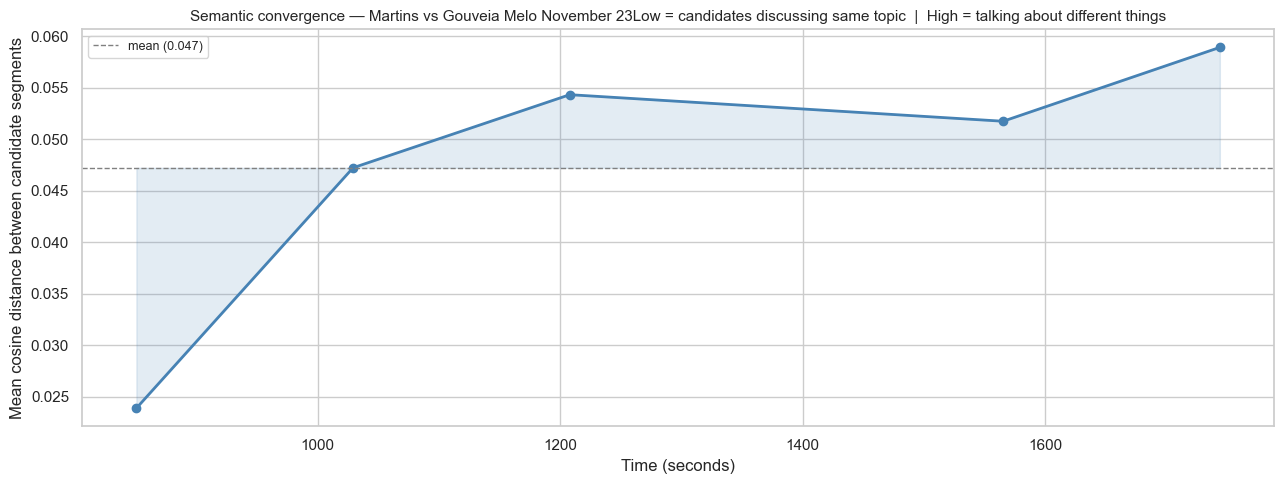

In [16]:
from scipy.spatial.distance import cdist as _cdist_conv

def _parse_emb(x):
    if isinstance(x, np.ndarray): return x
    return np.fromstring(str(x).strip("[]"), sep=" ")

# Load speech segments for this debate
ts_col     = "timestamp"
speech_raw = pd.read_pickle(os.path.join(FEATURES_DIR, f"{DEBATE}_speech.pkl"))
if ts_col not in speech_raw.columns: ts_col = "time stamp"

debate_audio = data[data["video"] == DEBATE][["time stamp", "speaker"]].copy()
speech = speech_raw.merge(debate_audio, left_on=ts_col, right_on="time stamp", how="left")
speech = speech[speech["speaker"].isin([FOCUS_SPEAKERS[0], FOCUS_SPEAKERS[1]])].copy()
speech = speech.sort_values(ts_col).reset_index(drop=True)
speech["emb"] = speech["text_embedding"].apply(_parse_emb)

# Bin debate into N time windows, compute mean cosine distance between the two speakers per bin
N_BINS = 10
t_min, t_max = speech[ts_col].min(), speech[ts_col].max()
speech["bin"] = pd.cut(speech[ts_col], bins=N_BINS, labels=False)

bin_rows = []
for b in range(N_BINS):
    sub = speech[speech["bin"] == b]
    A = [r for r in sub[sub["speaker"] == FOCUS_SPEAKERS[0]]["emb"].values]
    B = [r for r in sub[sub["speaker"] == FOCUS_SPEAKERS[1]]["emb"].values]
    if len(A) == 0 or len(B) == 0:
        continue
    dist = _cdist_conv(np.stack(A), np.stack(B), metric="cosine").mean()
    t_mid = t_min + (t_max - t_min) * (b + 0.5) / N_BINS
    bin_rows.append({"bin": b, "t_mid": t_mid, "cosine_distance": dist})

conv_df = pd.DataFrame(bin_rows)
mean_d  = conv_df["cosine_distance"].mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(conv_df["t_mid"], conv_df["cosine_distance"],
        marker="o", lw=2, color="steelblue")
ax.fill_between(conv_df["t_mid"], conv_df["cosine_distance"], mean_d,
                alpha=0.15, color="steelblue")
ax.axhline(mean_d, color="grey", ls="--", lw=1,
           label=f"mean ({mean_d:.3f})")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Mean cosine distance between candidate segments")
ax.set_title(
    f"Semantic convergence — {DEBATE.replace(chr(95), chr(32))}"
    "Low = candidates discussing same topic  |  High = talking about different things",
    fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()